Use version Python 3.11.3 

### CNN part of the pipeline classification

In [ ]:
#DEFAULT
import time
import os
#3RD PARTY
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
#CUSTOM

In [ ]:
# split dataset into training and test sets
train_size = 0.8
test_size = 0.2

labels_file = '../../data/training/training_dataset_labels_wo_manual_review.csv'
df = pd.read_csv(labels_file)
df = df.dropna(subset=['best_tool'])
# drop randomly from majority class to achieve a more balanced dataset
majority_class = df['best_tool'].value_counts().idxmax()
minority_class_count = df['best_tool'].value_counts().drop(majority_class)
majority_class_count = df['best_tool'].value_counts().max()
target_count = int(minority_class_count)
rows_to_drop = len(df[df['best_tool'] == majority_class]) - target_count
df_majority = df[df['best_tool'] == majority_class].sample(n=rows_to_drop, random_state=42)
df = df.drop(df_majority.index)

label_encoder = LabelEncoder()
df['best_tool_num'] = label_encoder.fit_transform(df['best_tool'])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label mapping:", label_mapping)

train_df, test_df = train_test_split(df, test_size=test_size, stratify=df['best_tool_num'], random_state=42)

train_df = train_df.rename(columns={'best_tool_num': 'best_tool_encoded'})
test_df = test_df.rename(columns={'best_tool_num': 'best_tool_encoded'})

print("Training set class distribution:")
print("Total images:", len(df))
print(f"Training images: {len(train_df)} ({(len(train_df)/len(df))*100:.2f}%)")
print(f"Test images: {len(test_df)} ({(len(test_df)/len(df))*100:.2f}%)")

print("Class distribution in full dataset:")
print(df['best_tool'].value_counts() / len(df) * 100)

print("Class distribution in training set:")
print(train_df['best_tool'].value_counts() / len(train_df) * 100)

# train_df.to_csv('../../data/training/train_labels.csv', index=False)
# train_df = train_df.sample(n=250, random_state=42).rename(columns={'best_tool_num': 'best_tool_encoded'})
# test_df.to_csv('../../data/training/test_labels.csv', index=False)
# test_df = test_df.sample(n=50, random_state=42).rename(columns={'best_tool_num': 'best_tool_encoded'})

with open('../../data/training/label_mapping.txt', 'w') as f:
    for label, num in label_mapping.items():
        f.write(f"{label}\t{num}\n")

Label mapping: {'herbonauten': np.int64(0), 'vouchervision': np.int64(1)}
Training set class distribution:
Total images: 874
Training images: 699 (79.98%)
Test images: 175 (20.02%)
Class distribution in full dataset:
best_tool
herbonauten      50.0
vouchervision    50.0
Name: count, dtype: float64
Class distribution in training set:
best_tool
vouchervision    50.071531
herbonauten      49.928469
Name: count, dtype: float64


C:\Users\mernst\AppData\Local\Temp\ipykernel_7864\1599867472.py:12: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  target_count = int(minority_class_count)


In [7]:
# Training dataset preparation
train_df = pd.read_csv('../../data/training/train_set.csv')
test_df = pd.read_csv('../../data/training/test_set.csv')

label_encoder = LabelEncoder()
label_encoder.fit(train_df['best_tool'])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label mapping:", label_mapping)

x_train = train_df.drop(columns=['best_tool', 'best_tool_encoded'])
y_train = train_df['best_tool_encoded']
x_test = test_df.drop(columns=['best_tool', 'best_tool_encoded'])
y_test = test_df['best_tool_encoded']

Label mapping: {'herbonauten': np.int64(0), 'vouchervision': np.int64(1)}


In [ ]:
class HerbariumImagesDataset(torch.utils.data.Dataset):

    def __init__(self, df, image_path, transform=None):
        self.labels = self._load_labels(df)
        self.image_dir = image_path
        self.transform = transform
        self.image_bboxes = pd.read_csv('../../data/training/bounding_boxes.csv', index_col=0).to_dict(orient='index')

    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, index):
        image_name = self.labels.iloc[index, 0]
        image_path = os.path.join(self.image_dir, image_name + '.jpg')
        label = self.labels.iloc[index, 1]
        image = Image.open(image_path).convert('RGB')
        bbox = self.image_bboxes.get(image_name, None)
        if bbox:
            image = image.crop((bbox['x_min'], bbox['y_min'], bbox['x_max'], bbox['y_max']))
        else:
            image = image.crop((0, image.height // 2, image.width, image.height))
        if self.transform:
            image = self.transform(image)
        return image, label

    def _load_labels(self, labels_file):
        df = labels_file.copy()
        print(df['best_tool_encoded'].value_counts())
        return df[['catalogNumber', 'best_tool_encoded']]
# TODO: Test AutoAugment policies = [v2.AutoAugmentPolicy.CIFAR10, v2.AutoAugmentPolicy.IMAGENET, v2.AutoAugmentPolicy.SVHN]

train_transform = transforms.Compose([ # Augmentation
    transforms.Resize((640, 640)),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.08), ratio=(0.3, 3.3))
])

test_transform = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = HerbariumImagesDataset(df=train_df, image_path='../../data/sample_images_stratified_after_filter/', transform=train_transform)
test_dataset = HerbariumImagesDataset(df=test_df, image_path='../../data/sample_images_stratified_after_filter/', transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

print("Number of training samples: " + str(len(train_dataset)))
print("Number of test samples: " + str(len(test_dataset)))

best_tool_encoded
1    350
0    349
Name: count, dtype: int64
best_tool_encoded
0    88
1    87
Name: count, dtype: int64
Number of training samples: 699
Number of test samples: 175


In [ ]:
# Model setup
models_dict = {
    'EfficientNet_B0': {
        'model': models.efficientnet_b0,
        'weights': models.EfficientNet_B0_Weights.IMAGENET1K_V1
    },
    # Uncomment if other architectures should be tested
    # 'EfficientNet_V2_S': {
    #     'model': models.efficientnet_v2_s,
    #     'weights': models.EfficientNet_V2_S_Weights.IMAGENET1K_V1
    # },
    # 'ResNet18': {
    #     'model': models.resnet18,
    #     'weights': models.ResNet18_Weights.IMAGENET1K_V1
    # },
    # 'MobileNet_V2': {
    #     'model': models.mobilenet_v2,
    #     'weights': models.MobileNet_V2_Weights.IMAGENET1K_V1
    # },
    # 'DenseNet121': {
    #     'model': models.densenet121,
    #     'weights': models.DenseNet121_Weights.IMAGENET1K_V1
    # },
    # 'Inception_V3': {
    #     'model': models.inception_v3,
    #     'weights': models.Inception_V3_Weights.IMAGENET1K_V1
    # },
    # 'Squeeznet1_0': {
    #     'model': models.squeezenet1_0,
    #     'weights': models.SqueezeNet1_0_Weights.IMAGENET1K_V1
    # },
    # 'Shufflenet_V2_X1_5': {
    #     'model': models.shufflenet_v2_x1_5,
    #     'weights': models.ShuffleNet_V2_X1_5_Weights.IMAGENET1K_V1
    # },
}    
    
def setup_model(model_name, num_classes=2):
    model_info = models_dict[model_name]
    model = model_info['model'](weights=model_info['weights'])
    for param in model.parameters(): # freeze all layers
        param.requires_grad = False
    # Different architectures require different layer modifications
    # 
    print("Model architecture:", model_name)
    if model_name.startswith('EfficientNet') or model_name.startswith('MobileNet'):
        features = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(
            nn.Dropout(p=0.5, inplace=True),
            nn.Linear(features, num_classes)
        )
        # unfreeze classification layer and last feature layer
        for param in model.classifier[1].parameters():
            param.requires_grad = True
        for param in model.features[6].parameters():
            param.requires_grad = True
    elif model_name.startswith('ResNet'):
        features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=0.5, inplace=True),
            nn.Linear(features, num_classes)
        )
        for param in model.fc.parameters():
            param.requires_grad = True
        for param in model.layer4.parameters():
            param.requires_grad = True
    elif model_name.startswith('DenseNet'):
        features = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.5, inplace=True),
            nn.Linear(features, num_classes)
        )
        for param in model.classifier.parameters():
            param.requires_grad = True
        for param in model.features.denseblock4.parameters():
            param.requires_grad = True
    elif model_name.startswith('Inception'):
        features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=0.5, inplace=True),
            nn.Linear(features, num_classes)
        )
        for param in model.fc.parameters():
            param.requires_grad = True
        for param in model.Mixed_7c.parameters():
            param.requires_grad = True
    elif model_name.startswith('REGNET'):
        features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=0.5, inplace=True),
            nn.Linear(features, num_classes)
        )
        for param in model.fc.parameters():
            param.requires_grad = True
        for param in model.trunk_output.block4.parameters():
            param.requires_grad = True
    elif model_name.startswith('Squeeznet'):
        features = model.classifier[1].in_channels
        model.classifier[1] = nn.Sequential(
            nn.Dropout(p=0.5, inplace=True),
            nn.Conv2d(features, num_classes, kernel_size=1)
        )
        for param in model.classifier[1].parameters():
            param.requires_grad = True
        for param in model.features[12].parameters():
            param.requires_grad = True
    elif model_name.startswith('Shufflenet'):
        features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=0.5, inplace=True),
            nn.Linear(features, num_classes)
        )
        for param in model.fc.parameters():
            param.requires_grad = True
        for param in model.conv5.parameters():
            param.requires_grad = True
    else:
        raise NameError(f"{model_name} not implemented.")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    return model



Training cycle for model: EfficientNet_B0


Setting up model...
Setting up model: EfficientNet_B0
Setting up optimizer for model: EfficientNet


Starting training...


Epoch 1/50


100%|██████████| 11/11 [00:40<00:00,  3.67s/it]


Best model saved with accuracy: 0.7714

Epoch 2/50


100%|██████████| 11/11 [00:34<00:00,  3.11s/it]


Epoch 3/50


...

Epoch 11/50


100%|██████████| 11/11 [00:32<00:00,  3.00s/it]


Epoch 12/50


100%|██████████| 11/11 [00:43<00:00,  3.93s/it]


Early stopping triggered.

Training complete.



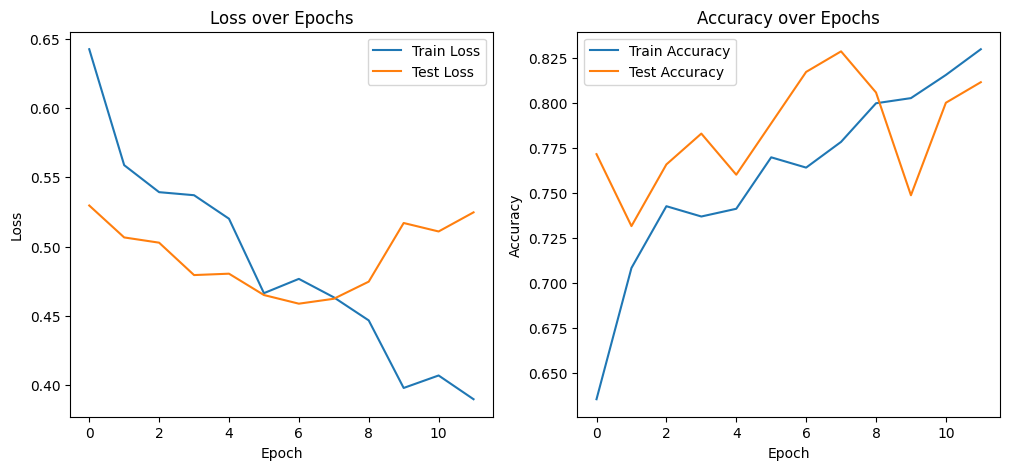

In [ ]:
# ES derived and modified from https://medium.com/biased-algorithms/a-practical-guide-to-implementing-early-stopping-in-pytorch-for-model-training-99a7cbd46e9d
class EarlyStopping: 
    def __init__(self, patience=5, delta=0.001):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, validation_loss):
        if self.best_loss is None:
            self.best_loss = validation_loss
        elif validation_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = validation_loss
            self.counter = 0
        
def train(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(dataloader, disable=False):
        inputs = inputs.to(device).float()
        labels = labels.to(device).long()

        optimizer.zero_grad()
        if model.__class__.__name__.startswith('Inception'): # Inception output is a tuple
            outputs, _ = model(inputs)
        else:
            outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward() # Backpropagation
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1) # keep only the index of the class
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # calculation of epoch outcome (loss and accuracy)
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): # no backprpagation during evaluation
        for inputs, labels in tqdm(dataloader):
            inputs, labels = inputs.to(device).float(), labels.to(device).long()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def train_model(model, model_name, train_loader, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    criterion = nn.CrossEntropyLoss()
    print("Setting up optimizer for model: " + model.__class__.__name__)
    if model.__class__.__name__.startswith('EfficientNet') or model.__class__.__name__.startswith('MobileNet'):
        optimizer = optim.Adam(
            [
                {'params': model.features[6].parameters(), 'lr': 0.0001},
                {'params': model.classifier[1].parameters(), 'lr': 0.001}
            ],
            weight_decay=0.01
        )
    elif model.__class__.__name__.startswith('ResNet'):
        optimizer = optim.Adam(
            [
                {'params': model.layer4.parameters(), 'lr': 0.0001},
                {'params': model.fc.parameters(), 'lr': 0.001}
            ],
            weight_decay=0.01
        )
    elif model.__class__.__name__.startswith('DenseNet'):
        optimizer = optim.Adam(
            [
                {'params': model.features.denseblock4.parameters(), 'lr': 0.0001},
                {'params': model.classifier.parameters(), 'lr': 0.001}
            ],
            weight_decay=0.01
        )
    elif model.__class__.__name__.startswith('Inception'):
        optimizer = optim.Adam(
            [
                {'params': model.Mixed_7c.parameters(), 'lr': 0.0001},
                {'params': model.fc.parameters(), 'lr': 0.001}
            ],
            weight_decay=0.01
        )
    elif model.__class__.__name__.startswith('RegNet'):
        optimizer = optim.Adam(
            [
                {'params': model.trunk_output.block4.parameters(), 'lr': 0.0001},
                {'params': model.fc.parameters(), 'lr': 0.001}
            ],
            weight_decay=0.01
        )
    elif model.__class__.__name__.startswith('Squeeznet') or model.__class__.__name__.startswith('SqueezeNet'):
        optimizer = optim.Adam(
            [
                {'params': model.features[12].parameters(), 'lr': 0.0001},
                {'params': model.classifier[1].parameters(), 'lr': 0.001}
            ],
            weight_decay=0.01
        )
    elif model.__class__.__name__.startswith('Shufflenet') or model.__class__.__name__.startswith('ShuffleNet'):
        optimizer = optim.Adam(
            [
                {'params': model.conv5.parameters(), 'lr': 0.0001},
                {'params': model.fc.parameters(), 'lr': 0.001}
            ],
            weight_decay=0.01
        )
    else:
        raise NameError(f"Optimizer setup for {model.__class__.__name__} not implemented.")

    scheduler = ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5,     # Reduce LR by 50%
        patience=5,     # Wait 5 epochs before reducing
        min_lr=1e-6
    )   
    num_epochs = 50
    best_acc = 0.0

    print("\n" + "="* 18)
    print("\n Starting training...\n")
    print("="*18 + "\n")

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': [], 'epoch_time': []}
    # torch.set_printoptions(precision=6)

    early_stopping = EarlyStopping(patience=5, delta=0.001)
    best_test_loss = np.inf
    average_epoch_time = 0.0
    for epoch in range(num_epochs):
        start_time = time.time()
        print("Epoch " + str(epoch + 1) + f"/{num_epochs}")
        with open(f"final_debug_log_{model_name}.txt", "a") as log_file:
            log_file.write("\n" + "="*20 + "\n")
            log_file.write(f"Epoch {epoch + 1}/{num_epochs}\n")
            log_file.write("="*20 + "\n")
            log_file.write("Training samples: " + str(len(train_dataset)) + "\n")
        train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
        with open(f"final_debug_log_{model_name}.txt", "a") as log_file:
            log_file.write("Test samples: " + str(len(test_dataset)) + "\n")
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        scheduler.step(test_loss)

        # if tie in accuracy, prefer model with lower test loss
        if test_acc > best_acc or (test_acc == best_acc and test_loss < best_test_loss):
            best_acc = test_acc
            best_test_loss = test_loss
            torch.save(model.state_dict(), 'final_best_model_' + model_name + '.pth')
            print(f"Best model saved with accuracy: {best_acc:.4f}\n")

        end = time.time()
        epoch_time = end - start_time
        average_epoch_time = (average_epoch_time * epoch + epoch_time) / (epoch + 1)

        with open(f"final_training_log_{model_name}.txt", "a") as log_file:
            log_file.write(" Epoch " + str(epoch + 1) + "/" + str(num_epochs) + "\n")
            log_file.write(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}\n")
            log_file.write(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}\n\n")
            log_file.write(f"Epoch time: {epoch_time:.2f} seconds, Average epoch time: {average_epoch_time:.2f} seconds\n\n")

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['epoch_time'].append(epoch_time)

        early_stopping(test_loss)
        if early_stopping.early_stop:
            print("Early stopping triggered.")
            break

    # plot training history
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['test_loss'], label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['test_acc'], label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()
    plt.savefig('final_training_history_' + model_name + '.png') # TODO: EfficientNets with same name will overwrite each other 

    print("="*20 + "\n")
    print("Training complete.")
    print("="*20 + "\n")

    return history

histories = {}

for key, value in models_dict.items(): # iterate over CNN models and train them
    print(f"\n{'='*18}")
    print(f"\nTraining cycle for model: {key}")
    print(f"\n{'='*18}")
    print(f"\nSetting up model...")
    model = setup_model(key)
    history = train_model(model, key, train_loader, test_loader)
    histories[key] = history

In [ ]:
histories_df = pd.DataFrame(histories)
histories_df

,EfficientNet_B0,EfficientNet_V2_S,ResNet18,MobileNet_V2,DenseNet121,Inception_V3,Squeeznet1_0,Shufflenet_V2_X1_5
train_loss,"[0.6506466621702368, 0.5625253461978652, 0.547...","[0.6137816377661445, 0.5240594636310231, 0.472...","[0.7142255780371752, 0.5514869930391962, 0.553...","[0.7001823356205766, 0.6453055583617904, 0.616...","[0.633877506987615, 0.6078886450691656, 0.5403...","[0.6563941091299057, 0.5663687227801844, 0.528...","[0.6339619159698486, 0.574894247407263, 0.5467...","[0.6482697420499541, 0.5922995067455552, 0.569..."
train_acc,"[0.6180257510729614, 0.7138769670958512, 0.713...","[0.6580829756795422, 0.7668097281831188, 0.771...","[0.6580829756795422, 0.7339055793991416, 0.743...","[0.5894134477825465, 0.6437768240343348, 0.679...","[0.6280400572246065, 0.6995708154506438, 0.743...","[0.6409155937052933, 0.7138769670958512, 0.739...","[0.6437768240343348, 0.7124463519313304, 0.728...","[0.6266094420600858, 0.6895565092989986, 0.711..."
test_loss,"[0.5323873975060203, 0.5038513947616924, 0.488...","[0.4933507198637182, 0.5277824943715875, 0.517...","[0.5025172450325706, 0.484442028132352, 0.5063...","[0.5555523823608052, 0.5249607292088595, 0.516...","[0.5072780468247153, 0.4930870641361583, 0.479...","[0.598885408856652, 0.4839597588235682, 0.4716...","[0.5641098293391141, 0.5348969806324352, 0.535...","[0.5554471043023196, 0.5175631750713695, 0.504..."
test_acc,"[0.7485714285714286, 0.7485714285714286, 0.771...","[0.76, 0.7314285714285714, 0.7542857142857143,...","[0.7542857142857143, 0.7942857142857143, 0.794...","[0.7085714285714285, 0.7257142857142858, 0.725...","[0.7657142857142857, 0.7885714285714286, 0.788...","[0.68, 0.8, 0.8, 0.7657142857142857, 0.7371428...","[0.7428571428571429, 0.7485714285714286, 0.742...","[0.7142857142857143, 0.7714285714285715, 0.771..."
epoch_time,"[297.8074064254761, 283.51941680908203, 284.49...","[623.0768628120422, 621.4564645290375, 624.185...","[288.66898345947266, 288.1093888282776, 289.66...","[244.55695509910583, 241.89991784095764, 246.0...","[654.0716972351074, 591.5656895637512, 632.372...","[540.7084982395172, 497.6488687992096, 499.694...","[248.81710124015808, 249.420227766037, 249.727...","[151.07327437400818, 151.76420521736145, 151.0..."


In [ ]:
# All models in histories ranked by their best test accuracy
performances = histories_df.loc['test_acc'].apply(lambda x: max(x)).sort_values(ascending=False)
average_epoch_times = histories_df.loc['epoch_time'].apply(lambda x: np.mean(x))
number_of_epochs = histories_df.loc['epoch_time'].apply(lambda x: len(x))
df_model_performances = pd.DataFrame({
    'model': performances.index,
    'best_test_acc': performances.values,
    'average_epoch_time': average_epoch_times.values,
    'number_of_epochs': number_of_epochs.values
})
df_model_performances

,model,best_test_acc,average_epoch_time,number_of_epochs
0,EfficientNet_B0,0.822857,281.054932,14
1,Shufflenet_V2_X1_5,0.822857,641.029739,9
2,DenseNet121,0.817143,288.696846,9
3,EfficientNet_V2_S,0.800000,267.899133,9
4,Inception_V3,0.800000,595.525641,9
5,ResNet18,0.794286,502.566226,8
6,Squeeznet1_0,0.794286,249.226098,11
7,MobileNet_V2,0.760000,152.817602,25


In [ ]:
# The best model is copied to the models folder / CNN
best_model_name = df_model_performances.iloc[0]['model']
os.rename('final_best_model_' + best_model_name + '.pth', '../../models/CNN/final_best_model_' + best_model_name + '.pth')

In [ ]:
# Confusion matrix and classification report
label_encoder = LabelEncoder()
label_encoder.fit(train_df['best_tool'])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label mapping:", label_mapping)

model.load_state_dict(torch.load('best_model_effnet_b0.pth'))
model.eval()
all_labels = []
all_preds = []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader):
        inputs = inputs.to(device).float()
        labels = labels.to(device).long()
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
cm = confusion_matrix(all_labels, all_preds)
cr = classification_report(all_labels, all_preds, target_names=label_mapping.keys())

for i, row in enumerate(cm): # Simple confusion matrix printout
    print(f"{list(label_mapping.keys())[i]}: ", end="")
    for val in row:
        print(f"{val} ", end="")
    print()
    
print("\nClassification Report:\n", cr)

Label mapping: {'herbonauten': np.int64(0), 'vouchervision': np.int64(1)}


100%|██████████| 11/11 [00:33<00:00,  3.01s/it]

herbonauten: 79 9 
vouchervision: 19 68 

Classification Report:
                precision    recall  f1-score   support

  herbonauten       0.81      0.90      0.85        88
vouchervision       0.88      0.78      0.83        87

     accuracy                           0.84       175
    macro avg       0.84      0.84      0.84       175
 weighted avg       0.84      0.84      0.84       175

